# Animated plot for the function:

$x(t) = 500 \cdot t \quad \text{km/h}$

$y(t) = 8 - 600 \cdot t ^ 2 + 2000 \cdot t ^ 3 \quad \text{km/h}$

$\text{with} \quad 0 \le t \le 0.2 \quad \text{h}$

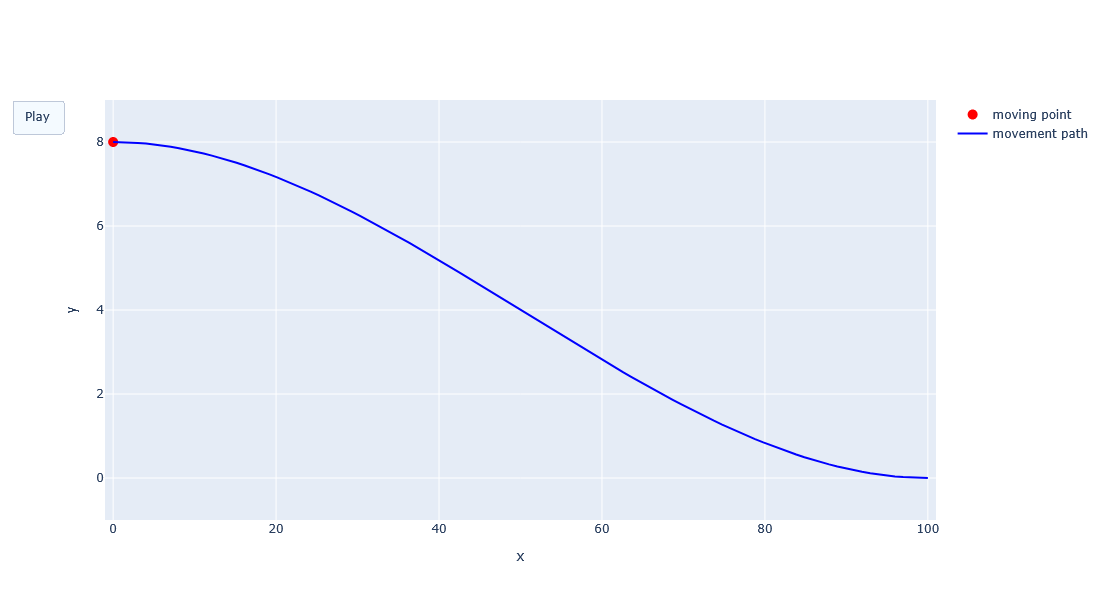

In [1]:
#-----------------------------------------------------------------------------#
#  Imports                                                                    #      
#-----------------------------------------------------------------------------#
import plotly.graph_objects as go
import numpy as np

#-----------------------------------------------------------------------------#
#  Input values and math functions                                            #      
#-----------------------------------------------------------------------------#
# Parameter range
t_min = 0.0
t_max = 0.2

# Amount of steps for entire function curve
curve_steps = 100

# Amount of steps for moving point
move_point_steps = 750

# Size of white space between curves and plot border
white_space = 1

def plot_func(t):
    """Calculate position and velocity of moving point (that traces out the curve)."""
    px = 500 * t
    py = 8 - 600 * t ** 2 + 2000 * t ** 3
    vx = 500
    vy = -1200 * t + 6000 * t ** 2
    ax = 0
    ay = -1200 + 12000 * t
    return px, py, vx, vy, ax, ay


#-----------------------------------------------------------------------------#
#  Figure setup                                                               #      
#-----------------------------------------------------------------------------#
# Calculate curve data
t_curve = np.linspace(0, 0.2, curve_steps)
px, py, vx, vy, ax, ay = plot_func(t_curve)

# Calculate marker data
t_point = np.linspace(0, 0.2, move_point_steps)
pxx, pyy, vxx, vyy, axx, ayy = plot_func(t_point)

# Calculate plot figure limits
x_min = np.min(px) - white_space
x_max = np.max(px) + white_space
y_min = np.min(py) - white_space
y_max = np.max(py) + white_space

# Contruct play button
animate_func_args = [
    None,
    {
        "frame": {
            "duration": 10,
            "redraw": False
        },
     "fromcurrent": True,
     "transition": {"duration": 10}
    }
] 
play_button = go.layout.updatemenu.Button(
    label="Play",
    method="animate",
    args=animate_func_args,
)

# Construct control menu with buttons
control_menu = go.layout.Updatemenu(
    type="buttons",
    buttons=[play_button],
)

# Construct layout
layout = go.Layout(
    width=800,
    height=600,
    xaxis={
        "range": [x_min, x_max],
        "autorange": False,
        "zeroline": False,
    },
    yaxis={
        "range": [y_min, y_max],
        "autorange": False,
        "zeroline": False,
    },
    xaxis_title="x",
    yaxis_title="y",
    title={"text": ""},
    hovermode="closest",
    updatemenus=[control_menu],
) 

# Construct a frame for each time point for a moving marker
frames = []
for idx in range(move_point_steps):
    # Create marker dot
    marker_dot = go.Scatter(
        x=[pxx[idx]],
        y=[pyy[idx]],
        name="moving point",
        mode="markers",
        marker={
            "color": "red",
            "size": 10,
        }
    )
    # Create annotation numbers
    layout2 = go.Layout(
        annotations=[
            {
                "x": pxx[idx],
                "y": pyy[idx],
                "text": f"y'={vyy[idx]:.0f} km/h",
                #"text": f"y''={ayy[idx]:.0f} km/h^2",
                "showarrow": True,
                "arrowhead": 2,
                "ax": 20,
                "ay": -30,
            }
        ]
    )
    # Construct and store a new frame
    frame = go.Frame(
        data=[marker_dot],
        layout=layout2,
    )
    frames.append(frame)

# Create initial marker
init_marker = go.Scatter(
    x=[pxx[0]],
    y=[pyy[0]],
    name="moving point",
    mode="markers",
    marker={
        "color": "red",
        "size": 10,
    },
)

# Create trace for curve path
curve_trace = go.Scatter(
    x=px,
    y=py,
    name="movement path",
    mode="lines",
    line={
        "width": 2,
        "color": "blue",
    },
)

# Create figure
fig = go.Figure(
    data=[init_marker, curve_trace],
    layout=layout,
    frames=frames,
)

#-----------------------------------------------------------------------------#
#  Launch figure                                                              #      
#-----------------------------------------------------------------------------#
fig.show()
